In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
sales= pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/raw/sales_fact.csv")
products = pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/raw/products_master.csv")
suppliers = pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/raw/suppliers_master.csv")
inventory = pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/raw/inventory_snapshot.csv")

In [5]:
sales['date'] = pd.to_datetime(sales['date'])

/var/folders/qm/8t8rxfy10f7b3mdcgk6yhkgh0000gp/T/ipykernel_62265/1173596365.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales['date'] = pd.to_datetime(sales['date'])


In [ ]:
daily_sales = (sales.groupby('date')['units_sold'].sum().reset_index())

<Axes: xlabel='date'>

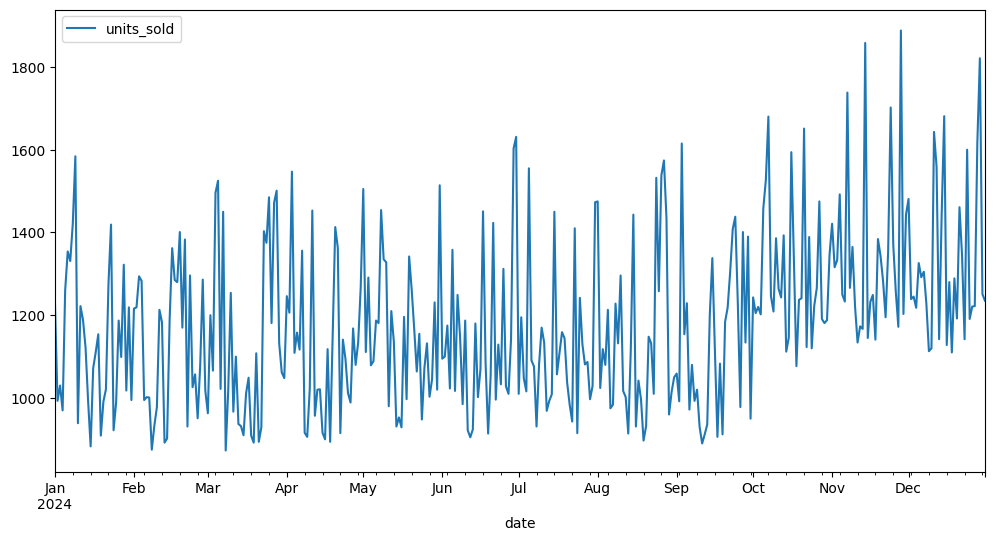

In [7]:
daily_sales.plot(
    x='date',
    y='units_sold',
    figsize=(12, 6),
)

In [8]:
# CAtegory Analysis

sales_product = sales.merge(products , on = 'sku_id' , how ='left')

In [9]:
category_sales = (sales_product.groupby('category')['units_sold'].sum().sort_values(ascending=False))

<Axes: xlabel='category'>

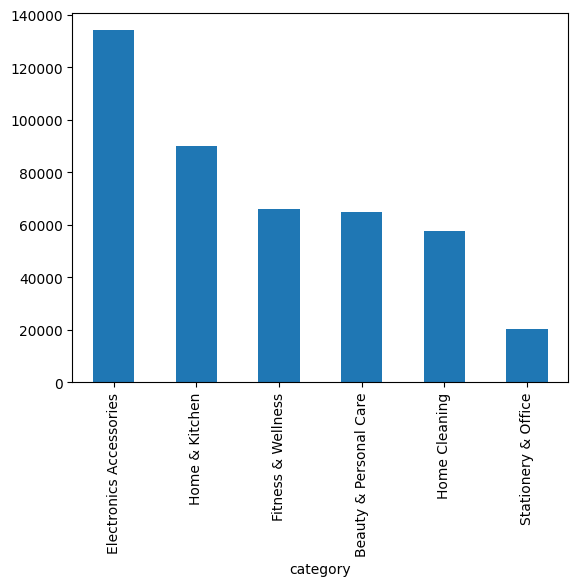

In [10]:
category_sales.plot(
    x='category',
    y='units_sold',
    kind = 'bar'
)
# Here we have found that the category with the highhest sales is the 'Electronics Accesories' followed by 'Home Appliances' and 'Mobile Phones'. This insight can help the company to focus on these categories for inventory optimization and marketing strategies.

In [11]:
sku_sales = (sales_product.groupby('sku_id')['units_sold'].sum().sort_values(ascending=False))

<Axes: xlabel='sku_id'>

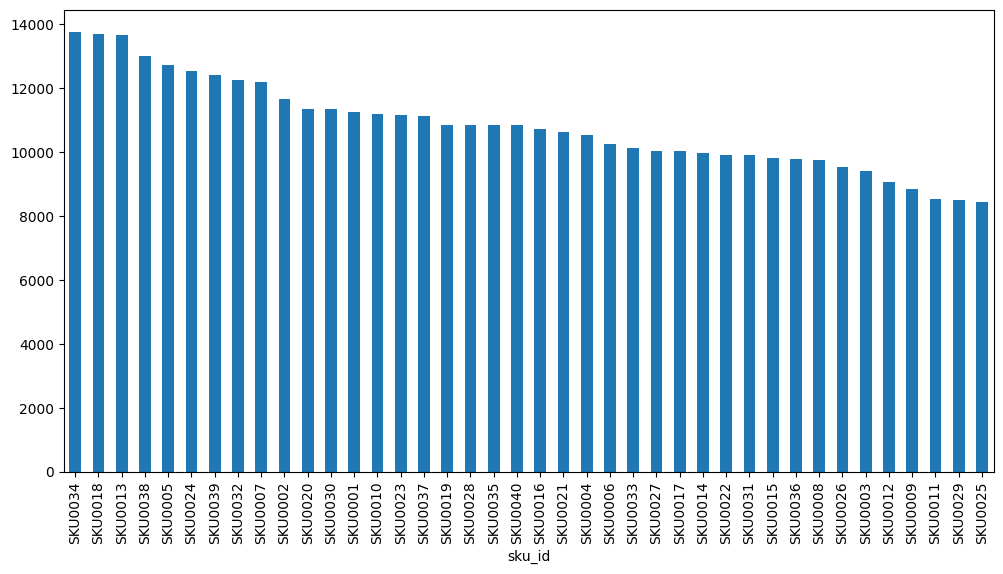

In [12]:
sku_sales.plot(
    x='sku_id',
    y='units_sold',
    kind = 'bar',
    figsize=(12,6)
)
# Top 10 SKUs with the highest sales. This insight can help the company to indentify  the most pop[ular products and ensure that they are well stocked to meet customer demand. Additionally, the company can analyze the characteristics of these top-selling SKUs to inform inventory optimization and marketing strategies for similar products.
# These will later become ABC classification of the products.

In [29]:
sales_promo=(sales.groupby('promo_flag')['units_sold'].sum())
sales_discount = (sales.groupby('discount_pct')['units_sold'].sum())
print(sales_promo)
print(sales_discount)
# This shows that the promoflag does not made much impact in increase in the demand

promo_flag
0    291819
1    140470
Name: units_sold, dtype: int64
discount_pct
0.0000     55
0.0001    370
0.0002    212
0.0003    356
0.0004    545
         ... 
0.4992     75
0.4994    164
0.4995     46
0.4996     41
0.4999     82
Name: units_sold, Length: 3405, dtype: int64


<Axes: xlabel='discount_pct'>

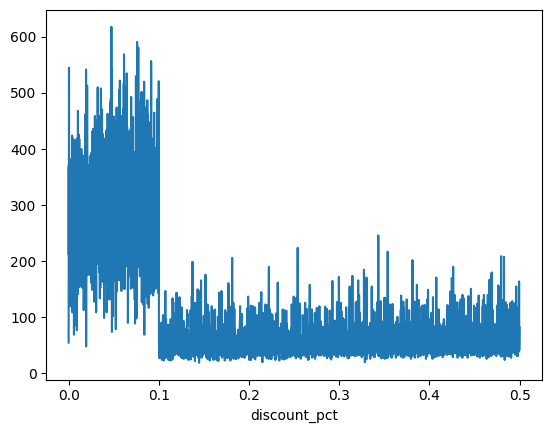

In [ ]:
sales_discount.plot(
    x='Discount',
    y ='Units_sold'
)
# From this graph we can interpret that the increase in discount precentage doesnot increase the demand

In [39]:
# Festival analysis
sales_fest = (sales.groupby('is_festival_month')['units_sold'].median())

In [40]:
sales_fest

is_festival_month
0    27.0
1    32.0
Name: units_sold, dtype: float64

In [41]:
sales.groupby('day_of_week')['units_sold'].mean()

day_of_week
0    29.191981
1    29.129245
2    29.191827
3    29.689423
4    28.816346
5    29.877885
6    30.812981
Name: units_sold, dtype: float64

In [45]:
sales.groupby('season_tag')['units_sold'].mean()

season_tag
festive    33.054620
monsoon    28.302869
summer     28.425543
winter     28.301667
Name: units_sold, dtype: float64